In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from functools import reduce

# 시각화 폰트 설정 (Windows 기준)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# data_sleep 폴더의 모든 .xpt 데이터 파일 임포트
sleep_data_path = 'data_sleep'
sleep_files = [f for f in os.listdir(sleep_data_path) if f.endswith('.xpt')]

sleep_dfs = {}
for file in sleep_files:
    file_path = os.path.join(sleep_data_path, file)
    # 확장자를 제외한 파일명을 키로 하여 데이터프레임 저장
    name = os.path.splitext(file)[0]
    try:
        sleep_dfs[name] = pd.read_sas(file_path, format='xport')
        print(f"Successfully loaded: {file}")
    except Exception as e:
        print(f"Error loading {file}: {e}")

print(f"\n총 {len(sleep_dfs)}개의 수면 데이터 파일을 로드했습니다.")

Successfully loaded: DEMO_D.xpt
Successfully loaded: DEMO_E.xpt
Successfully loaded: DEMO_F.xpt
Successfully loaded: DEMO_G.xpt
Successfully loaded: DEMO_H.xpt
Successfully loaded: DEMO_I.xpt
Successfully loaded: DEMO_J.xpt
Successfully loaded: DEMO_L.xpt
Successfully loaded: P_DEMO.xpt
Successfully loaded: P_SLQ.xpt
Successfully loaded: SLQ_D.xpt
Successfully loaded: SLQ_E.xpt
Successfully loaded: SLQ_F.xpt
Successfully loaded: SLQ_G.xpt
Successfully loaded: SLQ_H.xpt
Successfully loaded: SLQ_I.xpt
Successfully loaded: SLQ_J.xpt
Successfully loaded: SLQ_L.xpt

총 18개의 수면 데이터 파일을 로드했습니다.


In [3]:
# 각 주기(D, E, F, G, H, I, J, L, P)별로 DEMO와 SLQ 데이터를 조인하여 9개의 테이블 생성
cycles = ['D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'P']
combined_dfs = {}

for cycle in cycles:
    if cycle == 'P':
        demo_key = 'P_DEMO'
        slq_key = 'P_SLQ'
    else:
        demo_key = f'DEMO_{cycle}'
        slq_key = f'SLQ_{cycle}'
    
    if demo_key in sleep_dfs and slq_key in sleep_dfs:
        # SEQN을 기준으로 Inner Join 실행
        combined_dfs[cycle] = pd.merge(sleep_dfs[demo_key], sleep_dfs[slq_key], on='SEQN', how='inner')
        print(f"주기 {cycle}: {demo_key} 와 {slq_key} 조인 완료. 행/열: {combined_dfs[cycle].shape}")
    else:
        missing = []
        if demo_key not in sleep_dfs: missing.append(demo_key)
        if slq_key not in sleep_dfs: missing.append(slq_key)
        print(f"주기 {cycle}: 데이터를 찾을 수 없습니다. (누락: {', '.join(missing)})")

print(f"\n총 {len(combined_dfs)}개의 통합 테이블이 생성되었습니다.")

주기 D: DEMO_D 와 SLQ_D 조인 완료. 행/열: (6139, 70)
주기 E: DEMO_E 와 SLQ_E 조인 완료. 행/열: (6546, 70)
주기 F: DEMO_F 와 SLQ_F 조인 완료. 행/열: (6889, 46)
주기 G: DEMO_G 와 SLQ_G 조인 완료. 행/열: (6175, 51)
주기 H: DEMO_H 와 SLQ_H 조인 완료. 행/열: (6464, 50)
주기 I: DEMO_I 와 SLQ_I 조인 완료. 행/열: (6327, 54)
주기 J: DEMO_J 와 SLQ_J 조인 완료. 행/열: (6161, 56)
주기 L: DEMO_L 와 SLQ_L 조인 완료. 행/열: (8501, 33)
주기 P: P_DEMO 와 P_SLQ 조인 완료. 행/열: (10195, 39)

총 9개의 통합 테이블이 생성되었습니다.


In [4]:
# 생성된 모든 주기별 테이블을 하나로 수직 통합 (pd.concat)
final_list = []

for cycle, df in combined_dfs.items():
    # 데이터의 출처(주기)를 나타내는 컬럼 추가
    df = df.copy() # 원본 보존을 위해 카피본 사용
    df['CYCLE'] = cycle
    final_list.append(df)

# 모든 데이터프레임을 하나로 합침
sleep_final_df = pd.concat(final_list, axis=0, ignore_index=True)

print(f"최종 통합 완료! 전체 데이터 행/열: {sleep_final_df.shape}")
print(f"주기별 데이터 분포:\n{sleep_final_df['CYCLE'].value_counts().sort_index()}")

# 상위 5개 데이터 확인
sleep_final_df.head()

최종 통합 완료! 전체 데이터 행/열: (63397, 101)
주기별 데이터 분포:
CYCLE
D     6139
E     6546
F     6889
G     6175
H     6464
I     6327
J     6161
L     8501
P    10195
Name: count, dtype: int64


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,...,DMDHRMAZ,DMDHSEDZ,SLQ320,SLQ330,SLD013,DMDYRUSR,DMDMARTZ,DMDYRUSZ,WTINTPRP,WTMECPRP
0,31130.0,4.0,2.0,2.0,2.0,85.0,NaN,NaN,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,31131.0,4.0,2.0,2.0,2.0,44.0,535.0,536.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,31132.0,4.0,2.0,2.0,1.0,70.0,842.0,843.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31133.0,4.0,2.0,2.0,2.0,16.0,193.0,194.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31134.0,4.0,2.0,2.0,1.0,73.0,882.0,883.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# 데이터 전처리
analysis_df = sleep_final_df[['RIDAGEYR', 'SLD012', 'SLD013']].copy()
analysis_df = analysis_df[
    (analysis_df['SLD012'] > 0) & (analysis_df['SLD012'] < 24) & 
    (analysis_df['SLD013'] > 0) & (analysis_df['SLD013'] < 24)
]
analysis_df['AGE_GROUP'] = (analysis_df['RIDAGEYR'] // 10 * 10).astype(int)
analysis_df['AGE_GROUP_LABEL'] = analysis_df['AGE_GROUP'].apply(lambda x: f"{x}대")

# 시각화를 위해 Long-format으로 변환
melted_df = analysis_df.melt(
    id_vars=['AGE_GROUP_LABEL'], 
    value_vars=['SLD012', 'SLD013'],
    var_name='SLEEP_TYPE', 
    value_name='HOURS'
)
melted_df['SLEEP_TYPE'] = melted_df['SLEEP_TYPE'].map({'SLD012': '주중', 'SLD013': '주말'})

# 나이대 순서 정의
age_order = sorted(analysis_df['AGE_GROUP_LABEL'].unique())

### 수면 시간 분포

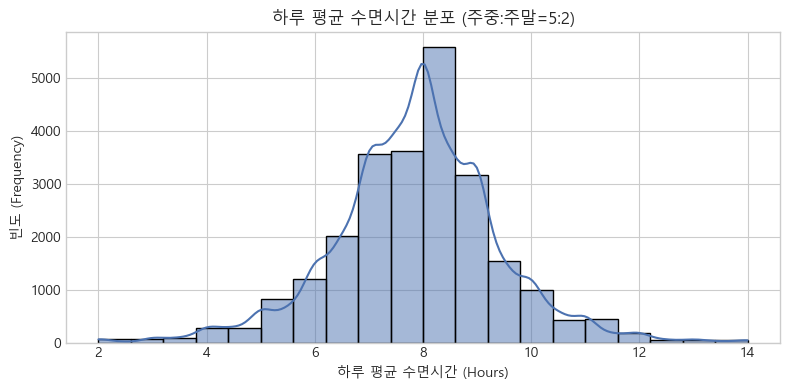

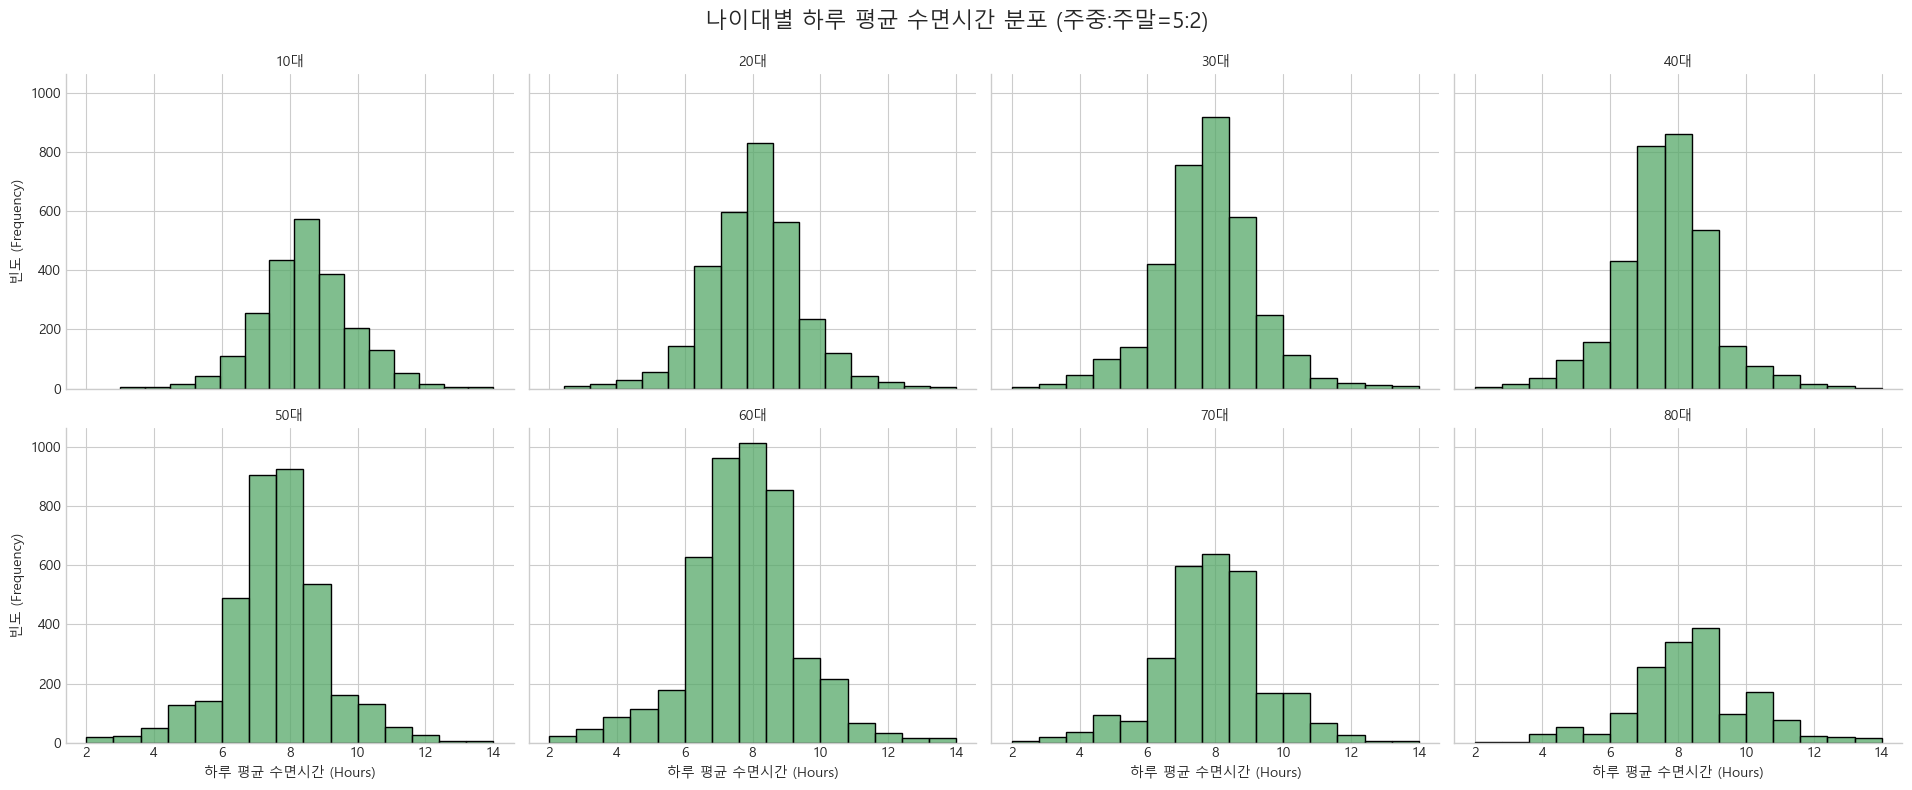

나이대별 하루 평균 수면시간(시간):
                 mean_daily_sleep
AGE_GROUP_LABEL                  
10대                      8.487590
20대                      8.053872
30대                      7.766139
40대                      7.631482
50대                      7.606508
60대                      7.737037
70대                      7.907151
80대                      8.381770


In [6]:
# 주중:주말 = 5:2 비율로 하루 평균 수면시간 계산
daily_df = analysis_df.copy()
daily_df["DAILY_SLEEP"] = (daily_df["SLD012"] * 5 + daily_df["SLD013"] * 2) / 7

# 전체 분포
plt.figure(figsize=(8, 4))
sns.histplot(daily_df["DAILY_SLEEP"], bins=20, kde=True, color="#4C72B0")
plt.title("하루 평균 수면시간 분포 (주중:주말=5:2)")
plt.xlabel("하루 평균 수면시간 (Hours)")
plt.ylabel("빈도 (Frequency)")
plt.tight_layout()
plt.show()

# 나이대별 분포
age_order = sorted(daily_df["AGE_GROUP_LABEL"].unique())
g = sns.FacetGrid(daily_df, col="AGE_GROUP_LABEL", col_wrap=4, height=4, aspect=1.2, col_order=age_order)
g.map_dataframe(sns.histplot, x="DAILY_SLEEP", bins=15, color="#55A868")
g.set_axis_labels("하루 평균 수면시간 (Hours)", "빈도 (Frequency)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("나이대별 하루 평균 수면시간 분포 (주중:주말=5:2)", fontsize=16)
plt.show()

# 요약 통계
daily_stats = daily_df.groupby("AGE_GROUP_LABEL")["DAILY_SLEEP"].mean().to_frame("mean_daily_sleep")
print("나이대별 하루 평균 수면시간(시간):")
print(daily_stats)

In [7]:
def get_nsf_range(age_years):
    for item in NSF_SLEEP_RANGES:
        if item["min_age"] <= age_years < item["max_age"]:
            return item
    return None

def calc_deviation_hours(actual_hours, min_hours, max_hours):
    if actual_hours < min_hours:
        return float(actual_hours - min_hours)
    if actual_hours > max_hours:
        return float(actual_hours - max_hours)
    return 0.0

In [8]:
# 하루 평균 수면(주중:주말=5:2) 기준, 10세 단위 나이대별 권장 수면 이탈 백분위 계산
daily_long = daily_df[["RIDAGEYR", "AGE_GROUP_LABEL", "DAILY_SLEEP"]].copy()

# NSF(National Sleep Foundation) 권장 수면 시간 범위 (나이대별)
NSF_SLEEP_RANGES = [
    {"label": "신생아(0-3개월)", "min_age": 0.0, "max_age": 0.25, "min_hours": 14, "max_hours": 17},
    {"label": "영아(4-11개월)", "min_age": 0.25, "max_age": 1.0, "min_hours": 12, "max_hours": 15},
    {"label": "유아(1-2세)", "min_age": 1.0, "max_age": 3.0, "min_hours": 11, "max_hours": 14},
    {"label": "미취학(3-5세)", "min_age": 3.0, "max_age": 6.0, "min_hours": 10, "max_hours": 13},
    {"label": "학령기(6-13세)", "min_age": 6.0, "max_age": 14.0, "min_hours": 9, "max_hours": 11},
    {"label": "청소년(14-17세)", "min_age": 14.0, "max_age": 18.0, "min_hours": 8, "max_hours": 10},
    {"label": "성인(18-64세)", "min_age": 18.0, "max_age": 65.0, "min_hours": 7, "max_hours": 9},
    {"label": "노인(65세 이상)", "min_age": 65.0, "max_age": 200.0, "min_hours": 7, "max_hours": 8},
]

# 각 개인의 정확한 나이에 맞는 NSF 권장 범위 적용
daily_long["nsf_info"] = daily_long["RIDAGEYR"].apply(get_nsf_range)
daily_long = daily_long[daily_long["nsf_info"].notna()].copy()
daily_long["nsf_min"] = daily_long["nsf_info"].apply(lambda x: x["min_hours"])
daily_long["nsf_max"] = daily_long["nsf_info"].apply(lambda x: x["max_hours"])
daily_long = daily_long.drop(columns=["nsf_info"])

# 권장 범위에서의 이탈 시간 계산 (0 = 권장 범위 내)
daily_long["deviation_hours"] = daily_long.apply(
    lambda row: calc_deviation_hours(row["DAILY_SLEEP"], row["nsf_min"], row["nsf_max"]),
    axis=1,
)

percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
age_percentile_rows = []

# 10세 단위(AGE_GROUP_LABEL)로 그룹화하여 백분위 계산
for age_label, group_df in daily_long.groupby("AGE_GROUP_LABEL"):
    # 0퍼센타일: 권장 수면 범위를 지키고 있는 상태 (이탈 시간 0.0)
    age_percentile_rows.append({
        "age_group": age_label,
        "percentile": 0,
        "deviation_hours": 0.0,
    })

    # # 수면 부족과 과잉을 따로 계산하는 기존 로직 주석 처리
    # below = group_df[group_df["deviation_hours"] < 0]["deviation_hours"]
    # above = group_df[group_df["deviation_hours"] > 0]["deviation_hours"]

    # 절댓값으로 벗어난 정도 계산 (0 제외, 벗어난 사람들만)
    abs_deviation = group_df["deviation_hours"].abs()
    abs_deviation_nonzero = abs_deviation[abs_deviation > 0]

    for p in percentiles[1:]:
        # 벗어난 정도의 백분위 (절댓값 기준, 0 제외)
        if not abs_deviation_nonzero.empty:
            deviation = float(abs_deviation_nonzero.quantile(p / 100))
            age_percentile_rows.append({
                "age_group": age_label,
                "percentile": p,
                "deviation_hours": deviation,
            })
        # # 수면 부족 (음수 방향 백분위) - 주석 처리
        # if not below.empty:
        #     deviation = float(below.quantile(1 - p / 100))
        #     age_percentile_rows.append({
        #         "age_group": age_label,
        #         "percentile": -p,
        #         "deviation_hours": deviation,
        #     })
        # # 수면 과잉 (양수 방향 백분위) - 주석 처리
        # if not above.empty:
        #     deviation = float(above.quantile(p / 100))
        #     age_percentile_rows.append({
        #         "age_group": age_label,
        #         "percentile": p,
        #         "deviation_hours": deviation,
        #     })

# 결과 데이터프레임 생성 및 정렬
age_deviation_percentiles = pd.DataFrame(age_percentile_rows)
age_deviation_percentiles = age_deviation_percentiles.sort_values(
    ["age_group", "percentile"],
    ascending=[True, True],
).reset_index(drop=True)

print("나이대별(10세 단위) 권장 수면에서의 이탈 백분위 (단위: 시간)")
age_deviation_percentiles

나이대별(10세 단위) 권장 수면에서의 이탈 백분위 (단위: 시간)


,age_group,percentile,deviation_hours
0,10대,0,0.000000
1,10대,10,0.142857
2,10대,20,0.285714
3,10대,30,0.428571
4,10대,40,0.571429
...,...,...,...
83,80대,60,1.642857
84,80대,70,2.000000
85,80대,80,2.500000
86,80대,90,3.000000


### 비대칭 정규분포 

나이대별 하루 평균 수면시간 skew-normal MLE 추정치


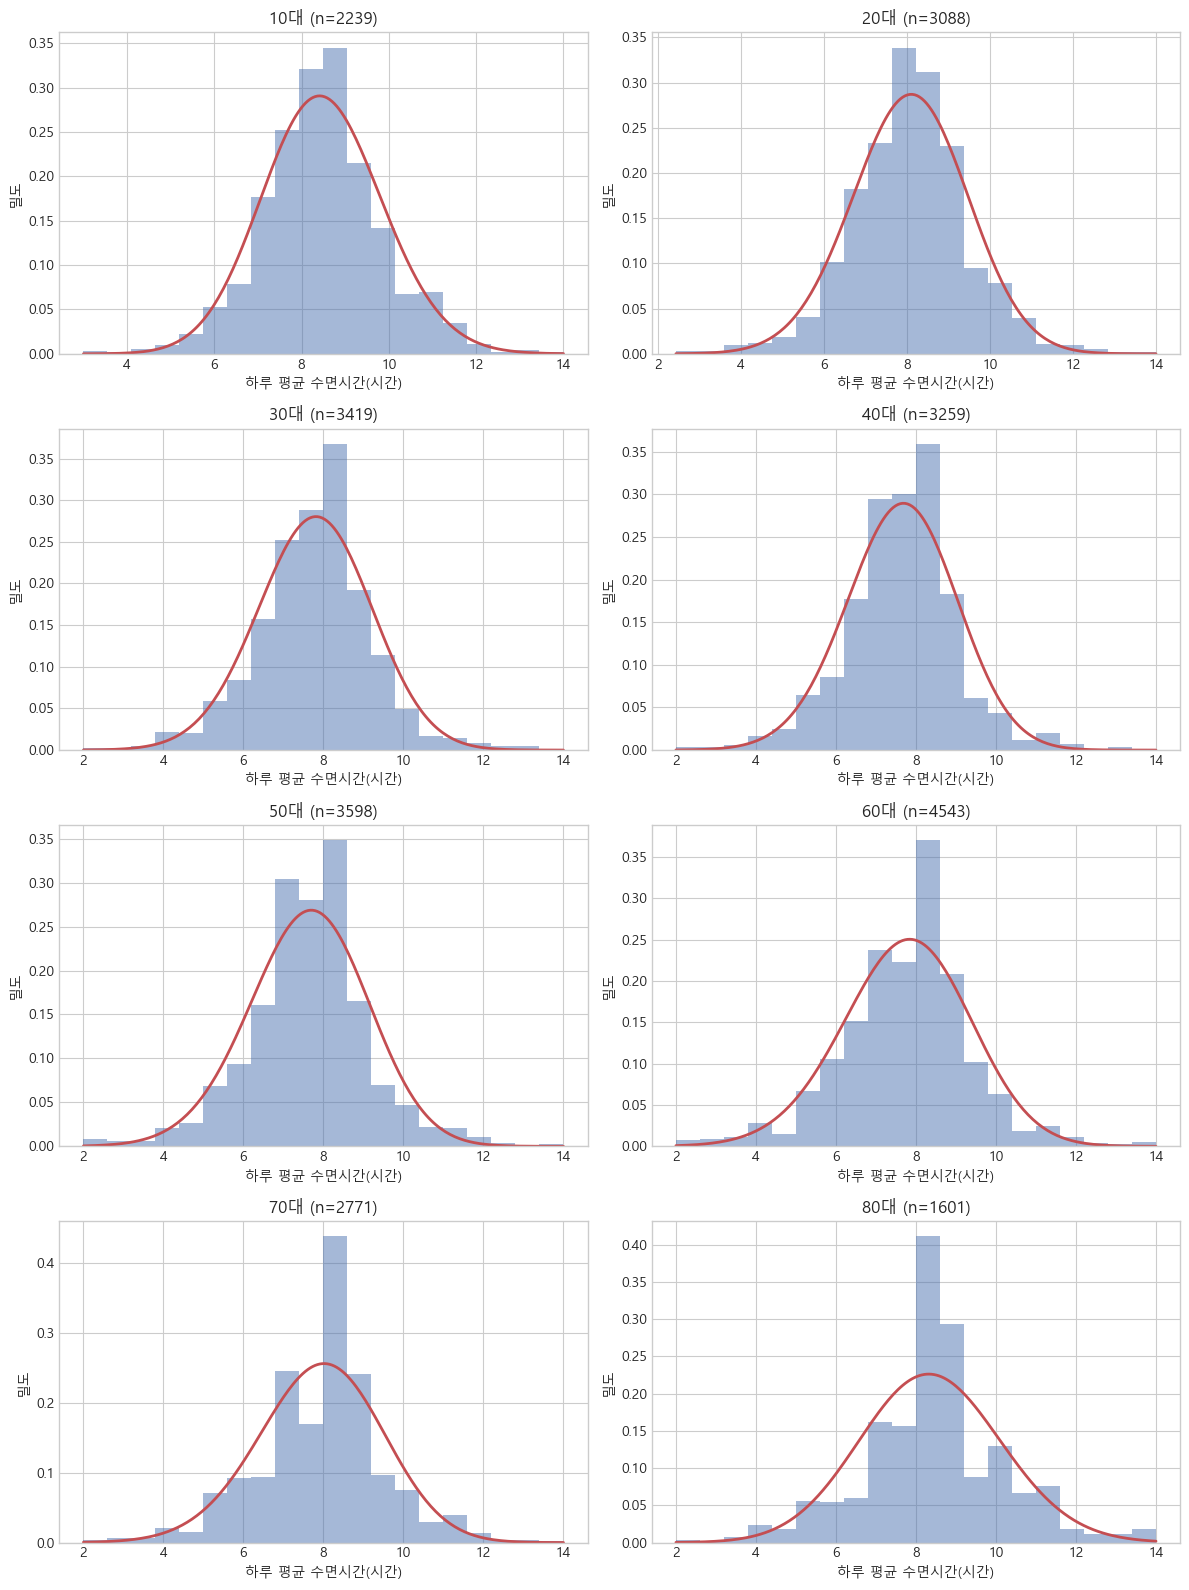

In [9]:
from scipy.stats import skewnorm

FIT_MIN_SAMPLES = 20
PDF_POINTS = 200
N_COLS = 2

fit_rows = []
plot_groups = []

for age_label, group_df in daily_df.groupby("AGE_GROUP_LABEL"):
    values = group_df["DAILY_SLEEP"].dropna().to_numpy()
    if values.size < FIT_MIN_SAMPLES:
        fit_rows.append(
            {
                "age_group": age_label,
                "n": int(values.size),
                "shape": np.nan,
                "loc": np.nan,
                "scale": np.nan,
            }
        )
        continue

    try:
        shape, loc, scale = skewnorm.fit(values)
        fit_rows.append(
            {
                "age_group": age_label,
                "n": int(values.size),
                "shape": float(shape),
                "loc": float(loc),
                "scale": float(scale),
            }
        )
        plot_groups.append((age_label, values, (shape, loc, scale)))
    except Exception as exc:
        fit_rows.append(
            {
                "age_group": age_label,
                "n": int(values.size),
                "shape": np.nan,
                "loc": np.nan,
                "scale": np.nan,
                "error": str(exc),
            }
        )

fit_df = pd.DataFrame(fit_rows).sort_values("age_group").reset_index(drop=True)
print("나이대별 하루 평균 수면시간 skew-normal MLE 추정치")
fit_df

if plot_groups:
    n_plots = len(plot_groups)
    n_rows = int(np.ceil(n_plots / N_COLS))
    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(12, 4 * n_rows),
        sharex=False,
        sharey=False,
    )
    axes = np.array(axes).reshape(-1)

    for ax, (age_label, values, params) in zip(axes, plot_groups):
        shape, loc, scale = params
        x_min = values.min()
        x_max = values.max()
        x = np.linspace(x_min, x_max, PDF_POINTS)
        pdf = skewnorm.pdf(x, shape, loc=loc, scale=scale)

        ax.hist(values, bins=20, density=True, alpha=0.5, color="#4C72B0")
        ax.plot(x, pdf, color="#C44E52", linewidth=2)
        ax.set_title(f"{age_label} (n={values.size})")
        ax.set_xlabel("하루 평균 수면시간(시간)")
        ax.set_ylabel("밀도")

    for ax in axes[n_plots:]:
        ax.axis("off")

    plt.tight_layout()
else:
    print("표본 수가 부족하여 시각화를 생략합니다.")


In [10]:
print(fit_df)

  age_group     n     shape       loc     scale
0       10대  2239  0.905283  7.613650  1.633885
1       20대  3088 -0.746705  8.810535  1.586747
2       30대  3419 -0.740260  8.535310  1.621969
3       40대  3259 -0.803095  8.428328  1.597566
4       50대  3598 -0.944116  8.582097  1.786283
5       60대  4543 -0.978729  8.813754  1.934301
6       70대  2771 -0.994905  8.973888  1.899595
7       80대  1601  0.753741  7.414182  2.016597


In [11]:
# ??: ??? ???? ?? ?? ?? ?? ??? ?? (???? ??)
from scipy.optimize import brentq

# NSF_SLEEP_RANGES ??? (? ???? ??)
NSF_SLEEP_RANGES = [
    {"label": "???(0-3??)", "min_age": 0.0, "max_age": 0.25, "min_hours": 14, "max_hours": 17},
    {"label": "??(4-11??)", "min_age": 0.25, "max_age": 1.0, "min_hours": 12, "max_hours": 15},
    {"label": "??(1-2?)", "min_age": 1.0, "max_age": 3.0, "min_hours": 11, "max_hours": 14},
    {"label": "???(3-5?)", "min_age": 3.0, "max_age": 6.0, "min_hours": 10, "max_hours": 13},
    {"label": "???(6-13?)", "min_age": 6.0, "max_age": 14.0, "min_hours": 9, "max_hours": 11},
    {"label": "???(14-17?)", "min_age": 14.0, "max_age": 18.0, "min_hours": 8, "max_hours": 10},
    {"label": "??(18-64?)", "min_age": 18.0, "max_age": 65.0, "min_hours": 7, "max_hours": 9},
    {"label": "??(65? ??)", "min_age": 65.0, "max_age": 200.0, "min_hours": 7, "max_hours": 8},
]

def get_nsf_range(age_years):
    for item in NSF_SLEEP_RANGES:
        if item["min_age"] <= age_years < item["max_age"]:
            return item
    return None

def out_of_range_mass(shape, loc, scale, nsf_min, nsf_max):
    cdf_min = skewnorm.cdf(nsf_min, shape, loc=loc, scale=scale)
    cdf_max = skewnorm.cdf(nsf_max, shape, loc=loc, scale=scale)
    mass = cdf_min + (1.0 - cdf_max)
    return float(np.clip(mass, 0.0, 1.0))

def abs_deviation_conditional_cdf(y, shape, loc, scale, nsf_min, nsf_max, out_mass):
    if y < 0:
        return 0.0
    if out_mass <= 0:
        return np.nan

    cdf_min = skewnorm.cdf(nsf_min, shape, loc=loc, scale=scale)
    cdf_max = skewnorm.cdf(nsf_max, shape, loc=loc, scale=scale)

    lower_part = cdf_min - skewnorm.cdf(nsf_min - y, shape, loc=loc, scale=scale)
    upper_part = skewnorm.cdf(nsf_max + y, shape, loc=loc, scale=scale) - cdf_max

    value = (lower_part + upper_part) / out_mass
    return float(np.clip(value, 0.0, 1.0))

def abs_deviation_quantile(percentile, shape, loc, scale, nsf_min, nsf_max):
    p = percentile / 100.0
    if p <= 0.0:
        return 0.0

    out_mass = out_of_range_mass(shape, loc, scale, nsf_min, nsf_max)
    if out_mass <= 0.0:
        return np.nan

    # skew-normal support is unbounded, so p=100 theoretical quantile is +inf.
    if p >= 1.0:
        return np.nan

    def objective(y):
        return abs_deviation_conditional_cdf(y, shape, loc, scale, nsf_min, nsf_max, out_mass) - p

    y_lo = 0.0
    y_hi = 0.5
    while objective(y_hi) < 0 and y_hi < 1e4:
        y_hi *= 2.0

    if objective(y_hi) < 0:
        return np.nan

    return float(brentq(objective, y_lo, y_hi, maxiter=200))

# ???? ?? ?? (??? ??)
age_representative = daily_df.groupby("AGE_GROUP_LABEL")["RIDAGEYR"].median().to_dict()

percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
model_percentile_rows = []

for _, row in fit_df.iterrows():
    age_label = row["age_group"]
    shape = row["shape"]
    loc = row["loc"]
    scale = row["scale"]

    if pd.isna(shape):
        continue

    # ?? ??? NSF ?? ????
    rep_age = age_representative.get(age_label, 30)  # ?? 30?
    nsf_info = get_nsf_range(rep_age)
    if nsf_info is None:
        continue

    nsf_min = nsf_info["min_hours"]
    nsf_max = nsf_info["max_hours"]

    for p in percentiles:
        deviation = abs_deviation_quantile(p, shape, loc, scale, nsf_min, nsf_max)
        model_percentile_rows.append(
            {
                "age_group": age_label,
                "percentile": p,
                "deviation_hours": deviation,
            }
        )

# ?? ??????
model_deviation_percentiles = pd.DataFrame(model_percentile_rows)
model_deviation_percentiles = model_deviation_percentiles.sort_values(
    ["age_group", "percentile"],
    ascending=[True, True],
).reset_index(drop=True)

print("\n??? ????(?? CDF) ?? ???? ?? ?? ?? ??? (??: ??)")
model_deviation_percentiles




??? ????(?? CDF) ?? ???? ?? ?? ?? ??? (??: ??)


,age_group,percentile,deviation_hours
0,10대,0,0.000000
1,10대,10,0.120349
2,10대,20,0.248096
3,10대,30,0.385311
4,10대,40,0.534944
...,...,...,...
83,80대,60,1.461567
84,80대,70,1.818958
85,80대,80,2.275422
86,80대,90,2.963192


In [ ]:
import os
import json
import pandas as pd

if "model_deviation_percentiles" not in globals():
    raise ValueError("model_deviation_percentiles is missing. Run the model percentile generation cell first.")
if "fit_df" not in globals():
    raise ValueError("fit_df is missing. Run the skew-normal fitting cell first.")

std_cols = [
    "source_notebook",
    "domain",
    "distribution",
    "age_group",
    "percentile",
    "target_steps",
    "percentile_value",
    "value_column",
    "param_s",
    "param_n",
    "param_p",
    "param_mu",
    "param_shape",
    "param_loc",
    "param_scale",
    "sample_size",
    "fit_method",
    "fit_params",
    "notes",
]

fit_params = fit_df[["age_group", "n", "shape", "loc", "scale"]].copy()
rows = model_deviation_percentiles.merge(fit_params, on="age_group", how="left")
rows = rows.rename(
    columns={
        "deviation_hours": "percentile_value",
        "n": "sample_size",
        "shape": "param_shape",
        "loc": "param_loc",
        "scale": "param_scale",
    }
)

rows["source_notebook"] = "DB_sleep_time.ipynb"
rows["domain"] = "sleep_time"
rows["distribution"] = "skewnorm"
rows["target_steps"] = pd.NA
rows["value_column"] = "deviation_hours"
rows["param_s"] = rows["param_shape"]
rows["param_n"] = pd.NA
rows["param_p"] = pd.NA
rows["param_mu"] = pd.NA
rows["fit_method"] = "MLE(skewnorm.fit)"
rows["notes"] = "Deviation from NSF recommended sleep duration; p=100 is theoretical +inf and stored as NaN"

rows["fit_params"] = rows.apply(
    lambda r: json.dumps(
        {
            "shape": None if pd.isna(r["param_shape"]) else float(r["param_shape"]),
            "loc": None if pd.isna(r["param_loc"]) else float(r["param_loc"]),
            "scale": None if pd.isna(r["param_scale"]) else float(r["param_scale"]),
            "s": None if pd.isna(r["param_s"]) else float(r["param_s"]),
        },
        ensure_ascii=False,
    ),
    axis=1,
)

rows = rows[std_cols]

output_path = "percentile.csv"
if os.path.exists(output_path):
    existing = pd.read_csv(output_path)
else:
    existing = pd.DataFrame(columns=std_cols)

for col in std_cols:
    if col not in existing.columns:
        existing[col] = pd.NA

existing = existing[~((existing["domain"] == "sleep_time") & (existing["distribution"] == "skewnorm"))].copy()
result = pd.concat([existing[std_cols], rows], ignore_index=True)
result = result.sort_values(["domain", "distribution", "age_group", "percentile"], kind="stable").reset_index(drop=True)
result.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Saved percentile table to: {os.path.abspath(output_path)}")
print("sleep_time/skewnorm rows written:", len(rows))

Saved percentile table to: c:\Users\user\Documents\Projects_src\DB\percentile.csv
sleep_time/skewnorm rows written: 88


C:\Users\user\AppData\Local\Temp\ipykernel_5852\1364707853.py:63: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([existing[std_cols], rows], ignore_index=True)
